# Исследование применимости обучения с подкреплением к задаче размещения сетевых функций в туманных вычислениях

# Применения обучения с подкреплением

Для применении метода "глубокое Q-обучение" необходимо сформулировать следующие компоненты: состояние, действие, функция награды. Для программирования этих компонент был использован фреймворк [Gymnasium](https://gymnasium.farama.org/index.html).

In [1]:
import greedy

res = greedy.find_greedy_solution1(6, 2, 3, [[1, 10, 100], [100, 10, 1]], [[0, 1, 10], [1, 0, 1], [10, 1, 0]], [3, 3], [1, 1, 1], [0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
x = greedy.find_obj([[1, 10, 100], [100, 10, 1]], [[0, 1, 10], [1, 0, 1], [10, 1, 0]], res)
print(x)

2


In [2]:
import numpy as np

np.set_printoptions(suppress=True, precision=5)

# Тестовые данные

Обучение модели происходит на реальных данных https://github.com/alibaba/clusterdata следующей размерности.


*   Количество сетевых функций: 2108
*   Количество приложений: 400
*   Количество вычислительных узлов: 10
*   Загруженность узлов: 85%

На этих данных размерность пространства состояний:


*   Пространство действий: 10
*   Пространство состояний: 29





In [3]:
import data

app_path = "users-melbcbd-generated.csv"
nodes_path = "site-optus-melbCBD.csv"
sfc_path = "batch_task.csv"
app_amount, comp_amount, app_comp_delay, comp_comp_delay = data.parse_edge_data(app_path, nodes_path, 400, 10)
function_amount, required_resources, sfc = data.parse_sfc_data(sfc_path, sfc_size=None)

In [4]:
comp_comp_delay

array([[0.     , 0.00652, 0.00147, 0.00174, 0.00535, 0.00515, 0.00283,
        0.00355, 0.00586, 0.00368],
       [0.00652, 0.     , 0.00557, 0.00491, 0.00166, 0.00215, 0.00532,
        0.00296, 0.00114, 0.00289],
       [0.00147, 0.00557, 0.     , 0.00173, 0.00469, 0.00392, 0.00139,
        0.00275, 0.00475, 0.00299],
       [0.00174, 0.00491, 0.00173, 0.     , 0.00363, 0.00389, 0.00285,
        0.00198, 0.0044 , 0.00202],
       [0.00535, 0.00166, 0.00469, 0.00363, 0.     , 0.00254, 0.00485,
        0.00194, 0.00201, 0.00171],
       [0.00515, 0.00215, 0.00392, 0.00389, 0.00254, 0.     , 0.00333,
        0.00208, 0.00103, 0.00228],
       [0.00283, 0.00532, 0.00139, 0.00285, 0.00485, 0.00333, 0.     ,
        0.00299, 0.00431, 0.00332],
       [0.00355, 0.00296, 0.00275, 0.00198, 0.00194, 0.00208, 0.00299,
        0.     , 0.00244, 0.00035],
       [0.00586, 0.00114, 0.00475, 0.0044 , 0.00201, 0.00103, 0.00431,
        0.00244, 0.     , 0.0025 ],
       [0.00368, 0.00289, 0.00299, 0.

In [5]:
function_amount_sampled, resources_sampled, sfc_sampled = data.sample_sfc(sfc, required_resources, app_amount, seed=43)
resources_sampled.size, np.sum(sfc_sampled), function_amount_sampled

(2097, 2097, 2097)

In [6]:
required_resources = required_resources * 0.5

In [7]:
comp_comp_delay.shape, app_comp_delay.shape, required_resources.shape, sfc.shape

((10, 10), (400, 10), (23208,), (4467,))

In [8]:
function_amount, app_amount, comp_amount, sum(required_resources), max(np.max(app_comp_delay), np.max(comp_comp_delay))

(23208, 400, 10, 94.13020051363856, 0.0067152027)

In [9]:
import gymnasium as gym
from vnfa import VNFA
from stable_baselines3.common.env_checker import check_env

# Register the environment so we can create it with gym.make()
# gym.register(
#     id="VNFA",
#     entry_point=VNFA,
#     max_episode_steps=300,  # Prevent infinite episodes
# )
    # FUNCTION_AMOUNT = 6
    # APP_AMOUNT = 2
    # COMP_AMOUNT = 3
    # APP_COMP_DELAY = np.array([[1, 10, 100], [100, 10, 1]], dtype=np.float32)
    # COMP_COMP_DELAY = np.array([[0, 1, 10], [1, 0, 1], [10, 1, 0]], dtype=np.float32)
    # SFC = np.array([3, 3], dtype=int)
    # AVAILABLE_RESOURCE = np.array([1, 1, 1], dtype=np.float32)
    # REQUIRED_RESOURCE = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=np.float32)
    # SFC_SIZE = 3
env = VNFA(app_amount=2, comp_amount=3, app_comp_delay=np.array([[1, 10, 100], [100, 10, 1]], dtype=np.float32),
           comp_comp_delay=np.array([[0, 1, 10], [1, 0, 1], [10, 1, 0]], dtype=np.float32), sfc=np.array([3, 3], dtype=int), 
           available_resources=np.ones(3, dtype=np.float32), required_resources=np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=np.float32))

check_env(env)

obs, info = env.reset(seed=42)  # Use seed for reproducible testing
print(f"Starting position - {obs}")

# Test each action type
actions = [0, 0, 0, 0, 0, 0]  # right, up, left, down
i = 0
while True:
# for action in actions:
    action = i % 2
    i += 1
    old_pos = f"{obs}"
    obs, reward, terminated, truncated, info = env.step(action)
    new_pos = f"{obs}"
    print(f"MASK {env.action_masks()} NEW: {new_pos} REWARD: {reward}")
    if terminated:
        break
# print(reward, i)

ERROR
Starting position - {'available_resources': array([1., 1., 1.], dtype=float32), 'delays': array([  1.,  10., 100.], dtype=float32), 'resources_queue': array([0.5, 0.5, 0.5], dtype=float32), 'F': array([0.], dtype=float32), 'sfc_delay': array([0.], dtype=float32)}
MASK [ True  True  True] NEW: {'available_resources': array([0.5, 1. , 1. ], dtype=float32), 'delays': array([ 0.,  1., 10.], dtype=float32), 'resources_queue': array([0.5, 0.5, 0. ], dtype=float32), 'F': array([1.], dtype=float32), 'sfc_delay': array([1.], dtype=float32)} REWARD: -1.0
MASK [ True  True  True] NEW: {'available_resources': array([0.5, 0.5, 1. ], dtype=float32), 'delays': array([1., 0., 1.], dtype=float32), 'resources_queue': array([0.5, 0. , 0. ], dtype=float32), 'F': array([2.], dtype=float32), 'sfc_delay': array([2.], dtype=float32)} REWARD: -1.0
MASK [False  True  True] NEW: {'available_resources': array([0. , 0.5, 1. ], dtype=float32), 'delays': array([100.,  10.,   1.], dtype=float32), 'resources_que

In [10]:
from tensorboard import notebook
import time
import IPython
import os

folder_path = 'C:\\Users\\Pusenkas\\AppData\\Local\\Temp\\.tensorboard-info' # Replace with your folder's path

# Check if the folder exists to prevent errors
if os.path.exists(folder_path) and os.path.isdir(folder_path):
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.remove(file_path) # Deletes the file
                print(f"Deleted file: {filename}")
        except Exception as e:
            print(f"Failed to delete {filename}. Reason: {e}")
else:
    print(f"Folder not found: {folder_path}")

# Specify your log directory
log_dir = "./vnfa_rl"

# Start the TensorBoard server
notebook.start("--logdir {} --host=127.0.0.1 --port=6006".format(log_dir))

# Wait a moment for the server to start (optional)
time.sleep(2)

# Display a button to open in a new tab (especially useful in environments like Google Colab)
# This code snippet provides a JS-based button to open the iframe source in a new window.
display(IPython.display.HTML('''
    <button id='open_tb' onclick="window.open(document.querySelector('iframe').src, '__blank')">Open TensorBoard in New Tab</button>
'''))


In [11]:
# from tensorboard import notebook
# notebook.list()

# Реализация "глубокого Q-обучения"

Воспользуемся библиотекой [stable-baseline3](https://github.com/DLR-RM/stable-baselines3), которая реализует большинство базовых методов обучения с подкреплением. Воспользуемся реализованным методом [Deep Q-learning](https://stable-baselines3.readthedocs.io/en/v1.0/modules/dqn.html). На основе предыдущих работ и в ходе эксперемнтов были подобраны следующие гиперпараметры, показывающие наилучшие результаты:
*   Архитектура многослойный перцептрона: имеющий два скрытых слоя по 64 нейрона в каждом
*   Доля времени, посвященная исследованию: 0.1



In [12]:
comp_comp_delay

array([[0.     , 0.00652, 0.00147, 0.00174, 0.00535, 0.00515, 0.00283,
        0.00355, 0.00586, 0.00368],
       [0.00652, 0.     , 0.00557, 0.00491, 0.00166, 0.00215, 0.00532,
        0.00296, 0.00114, 0.00289],
       [0.00147, 0.00557, 0.     , 0.00173, 0.00469, 0.00392, 0.00139,
        0.00275, 0.00475, 0.00299],
       [0.00174, 0.00491, 0.00173, 0.     , 0.00363, 0.00389, 0.00285,
        0.00198, 0.0044 , 0.00202],
       [0.00535, 0.00166, 0.00469, 0.00363, 0.     , 0.00254, 0.00485,
        0.00194, 0.00201, 0.00171],
       [0.00515, 0.00215, 0.00392, 0.00389, 0.00254, 0.     , 0.00333,
        0.00208, 0.00103, 0.00228],
       [0.00283, 0.00532, 0.00139, 0.00285, 0.00485, 0.00333, 0.     ,
        0.00299, 0.00431, 0.00332],
       [0.00355, 0.00296, 0.00275, 0.00198, 0.00194, 0.00208, 0.00299,
        0.     , 0.00244, 0.00035],
       [0.00586, 0.00114, 0.00475, 0.0044 , 0.00201, 0.00103, 0.00431,
        0.00244, 0.     , 0.0025 ],
       [0.00368, 0.00289, 0.00299, 0.

In [13]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3 import DQN
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback

env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount, dtype=np.float32), required_resources=required_resources)
check_env(env)

In [14]:
%load_ext autoreload
%autoreload 2

In [ ]:
%%time
import torch as th
import torch.nn as nn


# Collect data 
expert_obs = {"available_resources": [], "delays": [], "resources_queue": [], "F": [], "sfc_delay": []}
expert_actions = []
num_episode = 4000

for i in range(num_episode):
    if i % 250 == 0:
        print(f"Went through episode {i}")
    function_amount_sampled, resources_sampled, sfc_sampled = data.sample_sfc(sfc, required_resources, app_amount, seed=4242*(i**2) + 1337 * i + 777)
    res = greedy.find_greedy_solution1(function_amount=function_amount_sampled, app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
                   comp_comp_delay=comp_comp_delay, sfc=sfc_sampled, available_resources=np.ones(comp_amount), required_resources=resources_sampled)
    obs, info = env.custom_reset(function_amount_sampled, resources_sampled, sfc_sampled)
    for action_arr in res:
        for action in action_arr:
            expert_obs["available_resources"].append(obs["available_resources"])
            expert_obs["delays"].append(obs["delays"])
            expert_obs["resources_queue"].append(obs["resources_queue"])
            expert_obs["F"].append(obs["F"])
            expert_obs["sfc_delay"].append(obs["sfc_delay"])
            expert_actions.append(action)
            obs, reward, terminated, truncated, info = env.step(action)
    
expert_obs["available_resources"] = th.tensor(expert_obs["available_resources"])
expert_obs["delays"] = th.tensor(expert_obs["delays"])
expert_obs["resources_queue"] = th.tensor(expert_obs["resources_queue"])
expert_obs["F"] = th.tensor(expert_obs["F"])
expert_obs["sfc_delay"] = th.tensor(expert_obs["sfc_delay"])
expert_actions = th.tensor(expert_actions)

Went through episode 0
Went through episode 250
Went through episode 500
Went through episode 750
Went through episode 1000
Went through episode 1250
Went through episode 1500
Went through episode 1750
Went through episode 2000
Went through episode 2250
Went through episode 2500


In [ ]:
len(expert_actions)

In [ ]:
expert_actions[20000:20010], expert_obs["delays"][20000:20010]

In [ ]:
expert_actions.shape

In [ ]:
import torch
print(torch.cuda.is_available())

In [ ]:
import greedy

def test(trained_model, seed=43):    
    function_amount_sampled, resources_sampled, sfc_sampled = data.sample_sfc(sfc, required_resources, app_amount, seed=seed)
    env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount), required_resources=required_resources)    
    obs, info = env.custom_reset(function_amount_sampled, resources_sampled, sfc_sampled)
    start_time_rl = time.time()
    while True:
        action, _states = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated:
            end_time_rl = time.time()
            print(obs, reward)
            trained_model_f = obs["F"][0]
            break
    start_time_greed = time.perf_counter()
    res = greedy.find_greedy_solution1(function_amount=function_amount_sampled, app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc_sampled, available_resources=np.ones(comp_amount), required_resources=resources_sampled)
    end_time_greed = time.perf_counter()
    greedy_f = greedy.find_obj(app_comp_delay, comp_comp_delay, res)
    print(f"Greedy {greedy_f} time={end_time_greed - start_time_greed} vs Trained {trained_model_f} time={end_time_rl - start_time_rl}")

In [ ]:
def test_rl(trained_model, seed=43):
    function_amount_sampled, resources_sampled, sfc_sampled = data.sample_sfc(sfc, required_resources, app_amount, seed=seed)
    env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount), required_resources=required_resources)    
    obs, info = env.custom_reset(function_amount_sampled, resources_sampled, sfc_sampled)
    while True:
        action, _states = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated:
            trained_model_f = obs["F"][0]
            break
    return trained_model_f

In [ ]:
env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount, dtype=np.float32), required_resources=required_resources)
model = MaskablePPO("MultiInputPolicy", env, gamma = 1.0, learning_rate=0.0002, policy_kwargs = dict(net_arch=[64, 64]), verbose=0, 
                    tensorboard_log="./vnfa_rl/") #train_freq
test(model)

In [ ]:
num_epochs = 200

device = th.device("cuda")
print(f"Using device {device}| Data size {len(expert_actions)}")
policy = model.policy
optimizer = th.optim.Adam(policy.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
for epoch in range(num_epochs):
    start_time = time.perf_counter()
    batch_size = 200000
    for i in range(0, len(expert_actions), batch_size):
        batch_ops = {k: v[i:i+batch_size].to(device) for k, v in expert_obs.items()}
        batch_actions = expert_actions[i:i + batch_size].to(device)
        features = policy.extract_features(batch_ops)
        latent_pi, _ = policy.mlp_extractor(features)
        distribution = policy._get_action_dist_from_latent(latent_pi)
    
        logits = distribution.distribution.logits
        loss = loss_fn(logits, batch_actions)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    end_time = time.perf_counter()
    current_result = test_rl(model)
    print(f"Epoch {epoch} | Loss {loss.item()} | Res {current_result} | Time {end_time - start_time}")

In [ ]:
test(model)

In [ ]:
model.save("PretrainedPPO-64-64-good25")
# test(model)

In [ ]:
# env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
#                comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount, dtype=np.float32), required_resources=required_resources)
# check_env(env)
# model = MaskablePPO("MultiInputPolicy", env, gamma = 1.0, learning_rate=0.0003, policy_kwargs = dict(net_arch=[64, 64]), verbose=0, 
#                     tensorboard_log="./vnfa_rl/") #train_freq
# test(model)

In [ ]:
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
from stable_baselines3.common.monitor import Monitor

# 2. Wrap it with Monitor (essential for logging/evaluation)
# eval_env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
#                comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount, dtype=np.float32), required_resources=required_resources)

# eval_env = Monitor(eval_env)

# # Initialize evaluation callback
# eval_callback = MaskableEvalCallback(
#     eval_env, 
#     best_model_save_path="./logs/",
#     log_path="./logs/", 
#     eval_freq=1000,
#     deterministic=True, 
#     render=False
# )


# model.learn(total_timesteps=100000, callback=eval_callback)
model.load("PretrainedPPO-64-64-good(0.0062)")


# model.save("dqn_cartpole")
# del model # remove to demonstrate saving and loading
# model = DQN.load("dqn_cartpole")

In [ ]:
model2 = MaskablePPO("MultiInputPolicy", env, gamma = 1.0, learning_rate=0.0002, policy_kwargs = dict(net_arch=[64, 64]), verbose=0, 
                    tensorboard_log="./vnfa_rl/") #train_freq
model.learn(total_timesteps=100000)

In [ ]:
# model.save("PretrainedPPO-64-64-RL")

In [ ]:
model, model2

In [ ]:
model.load("good_logs2/best_model.zip", env=env)

In [ ]:
function_amount_sampled, resources_sampled, sfc_sampled = data.sample_sfc(sfc, required_resources, app_amount, seed=433)
alpha = 8
resources_sampled = [i/8.4 * alpha for i in resources_sampled]
print(sum(resources_sampled), comp_amount)
env = VNFA(app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
           comp_comp_delay=comp_comp_delay, sfc=sfc, available_resources=np.ones(comp_amount), required_resources=required_resources)    
obs, info = env.custom_reset(function_amount_sampled, resources_sampled, sfc_sampled)
i = 0
res = []
total_reward = 0
while True:
    action, _states = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
    res.append(action.item())
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    i += 1
    # print(obs)
    if terminated:
        print(i)
        print(obs, reward, total_reward)
        trained_model_f = obs["F"][0]
        break
res = greedy.find_greedy_solution1(function_amount=function_amount_sampled, app_amount=app_amount, comp_amount=comp_amount, app_comp_delay=app_comp_delay,
               comp_comp_delay=comp_comp_delay, sfc=sfc_sampled, available_resources=np.ones(comp_amount), required_resources=resources_sampled)
greedy_f = greedy.find_obj(app_comp_delay, comp_comp_delay, res)
print(f"Greedy res: {greedy_f}")

print(f"Final data for {sum(resources_sampled)/comp_amount}: RL|{total_reward}, Greedy|{greedy_f}, Calc|{-total_reward/3.67}")

# Результаты

*   Для поставленной задачи была сформулированна формальная постановка задачи, применимая к методам обучения с подкреплением
*   Были подготовлены реальные данные для эксперементального исследования
*   С помощью фреймворков Gymnasium и stable-baselines3 был реализован предложенный метод обучения с подкреплением. Была проверена его сходимость
*   Было подтверждено, что метод обучения с подкреплением: глубокое Q-обучение применим к поставленной задаче

Настройка используемого метода проводилась на основе следующих графиков:
1.   ep_len_mean: Отображается среденее количество шагов в эпизоде в процессе обучения. При успешной работе алгоритма все сетевые функции будут размещены, соответственно среднее количество шагов в эпизоде будет равно количеству сетевых функций (2108 на рассматриваемых данных). Необходимо стремиться к достижению максимального значения.
2.   ep_rew_mean: Значение средней накопленной награды в процессе обучения. Параметр, по которому происходит обучения модели.



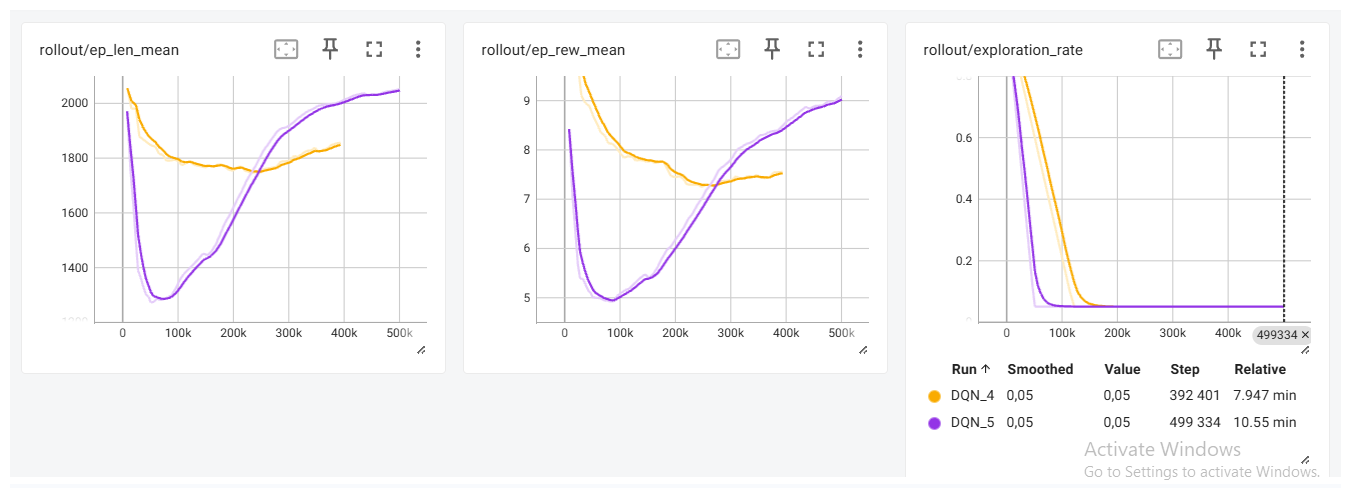




In [ ]:
env.success